<a href="https://colab.research.google.com/github/Shivssv1012/Deep-Learning-/blob/main/Dropout_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
X_train=np.linspace(-1,1,20)

In [4]:
X_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [5]:
y_train=np.array([-0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
    0.5524, 0.23115, 0.20835, 0.4211, 0.60485])

In [6]:
X_test=np.linspace(-1,1,20)

In [7]:
y_test = np.array([
    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
])

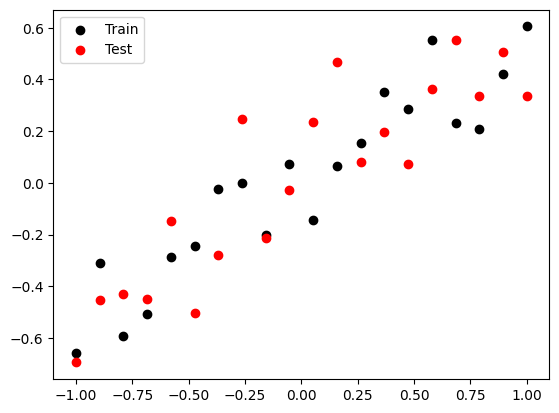

In [8]:
plt.scatter(X_train, y_train, c='black', label='Train' )
plt.scatter(X_test, y_test, c='red', label='Test')
plt.legend()
plt.show()

In [9]:
model=Sequential()
model.add(Dense(128, input_dim=1,activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500, verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#evaluate the model
_,train_mse=model.evaluate(X_train,y_train, verbose=0)
_,test_mse=model.evaluate(X_test,y_test, verbose=0)
print('Train MSE:', train_mse)
print('Test MSE:', test_mse)

Train MSE: 0.0010091442381963134
Test MSE: 0.04436185956001282


In [12]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


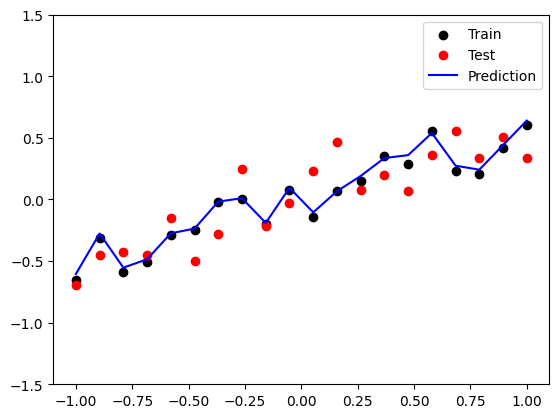

In [14]:
plt.figure()
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred, c='blue', label='Prediction')
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

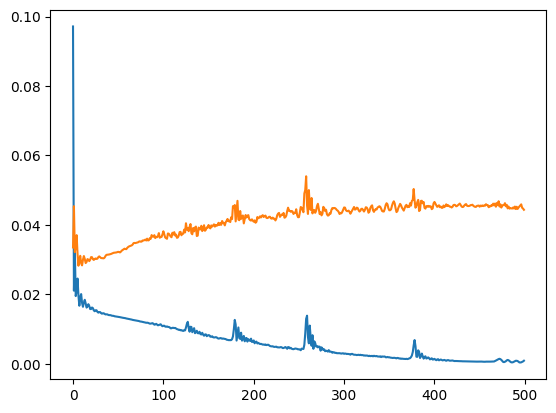

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

## **Dropout Implementation**

In [16]:
model=Sequential()
model.add(Dense(128, input_dim=1,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

adam=Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam, metrics=['mse'])
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500, verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
_,train_mse=model.evaluate(X_train,y_train,verbose=0)
_,test_mse=model.evaluate(X_test,y_test,verbose=0)
print('train_mse',train_mse)
print('test_mse',test_mse)

train_mse 0.011219953186810017
test_mse 0.03812112659215927


In [18]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


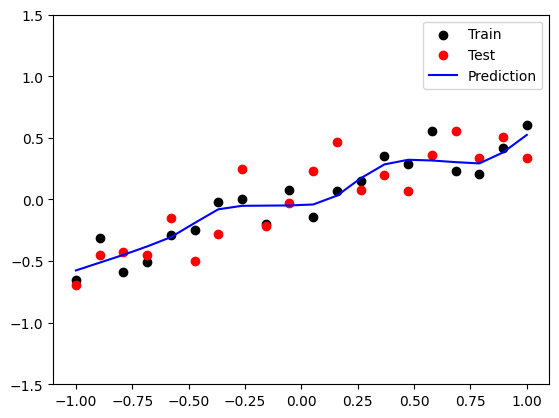

In [20]:
plt.figure()
plt.scatter(X_train,y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred, c='blue', label='Prediction')
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

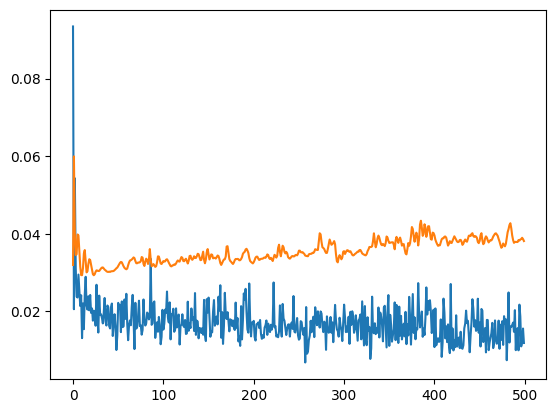

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])